In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load finalized datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

fire_core_df = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Fire_Core_Merged.csv")
fire_gust_df = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Fire_Gust_Merged.csv")

fire_core = fire_core_df.copy()
fire_gust = fire_gust_df.copy()

Mounted at /content/drive


/tmp/ipython-input-807/3670427169.py:4: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  fire_core_df = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Fire_Core_Merged.csv")
/tmp/ipython-input-807/3670427169.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  fire_gust_df = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Fire_Gust_Merged.csv")


##**(1) Fire Radiative Power EDA**

### Since no data were dropped in the final merge, use either dataset to complete fire intensity EDA

In [ ]:
# Check columns used for EDA are ready
print(fire_core.dtypes)

Fire_ID                           int64
Acquisition_Time                  int64
Year                              int64
Month                             int64
Day_of_Year                       int64
Hour                              int64
Latitude_Fire                   float64
Longitude_Fire                  float64
Bright_TI4                      float64
Bright_TI5                      float64
FRP                             float64
Scan                            float64
Track                           float64
Confidence                       object
DayNight                         object
Fire_Type                         int64
LC_Type1                          int64
LC_Label                         object
Confidence_Ordered                int64
detection_count                   int64
FRP_max                         float64
Date                             object
Nearest_Core_Station_Dist_km    float64
Climate_ID                       object
Station_Name                     object


In [ ]:
# Need to cap FRP at 0 as some values are negative (not physically meaningful for FRP)
fire_core["FRP_max"] = fire_core["FRP_max"].clip(lower=0)
fire_gust["FRP_max"] = fire_gust["FRP_max"].clip(lower=0)

# Check summary statistics for FRP values
pd.set_option('display.float_format', '{:.2f}'.format)
fire_core["FRP_max"].describe(percentiles=[0.9, 0.95, 0.99])


,FRP_max
count,2300610.00
mean,15.33
std,39.88
min,0.00
50%,4.30
90%,33.41
95%,64.43
99%,190.91
max,4191.10


In [ ]:
pd.reset_option('display.float_format')

### Plot FRP Distribution

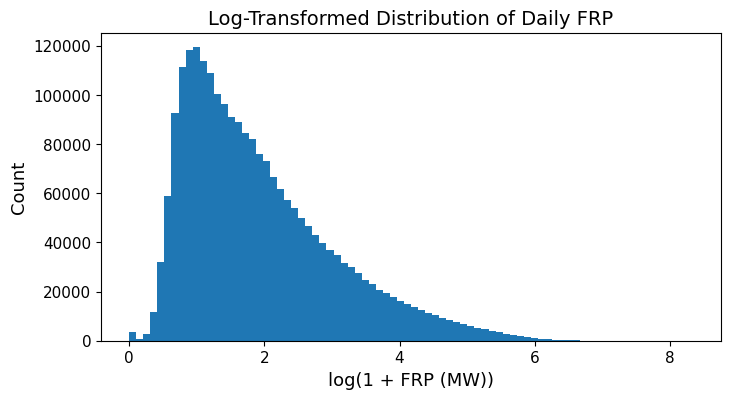

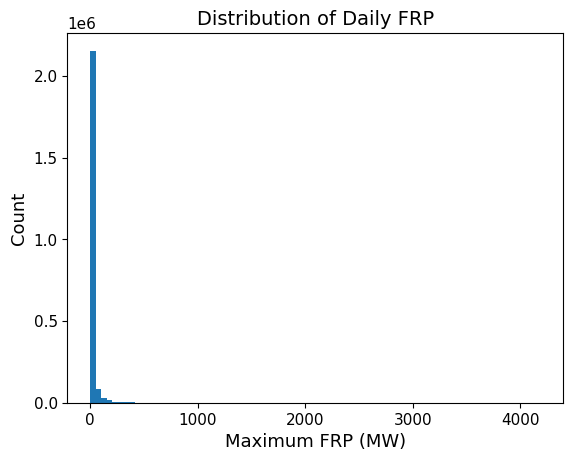

In [ ]:
x = fire_core['FRP_max']

# Log transformed plot
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(x), bins=80)
plt.xlabel('log(1 + FRP (MW))')
plt.ylabel('Count')
plt.title("Log-Transformed Distribution of Daily FRP")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.show

# Normal plot (hard to read)
plt.figure()
plt.hist(x, bins=80)
plt.xlabel("Maximum FRP (MW)")
plt.ylabel("Count")
plt.title("Distribution of Daily FRP")
plt.show()

### Boxplots of FRP by Month

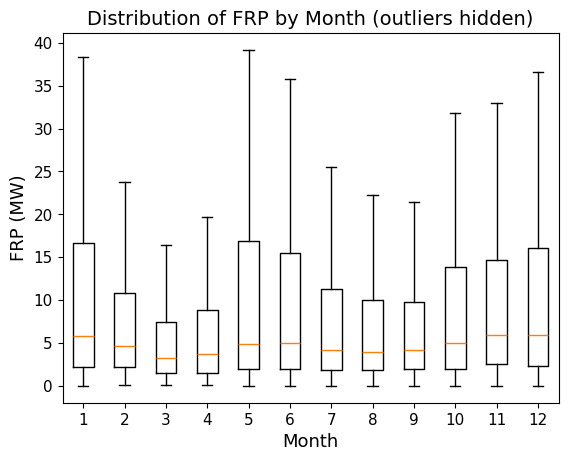

In [ ]:
# Create boxplot analysis subset and ensure 'Month' is read properly
box_subset = fire_core.dropna(subset=["Month", "FRP_max"]).copy()
box_subset["Month"] = box_subset["Month"].astype(int)

# Prepare data in month order
data_by_month = [box_subset.loc[box_subset["Month"] == m, "FRP_max"].values for m in range(1, 13)]

plt.figure()
plt.boxplot(data_by_month, showfliers=False) # remove outliers for readability
plt.xlabel("Month")
plt.ylabel("FRP (MW)")
plt.title("Distribution of FRP by Month (outliers hidden)")
plt.xticks(ticks=range(1, 13), labels=[str(m) for m in range(1, 13)])
plt.show()


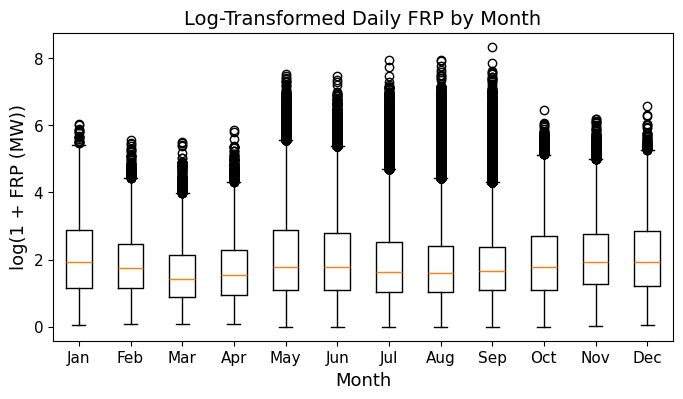

In [ ]:
import calendar

data_by_month_log = [np.log1p(box_subset.loc[box_subset["Month"] == m, "FRP_max"].values) for m in range(1, 13)]

plt.figure(figsize=(8, 4))
plt.boxplot(data_by_month_log)
plt.xlabel("Month")
plt.ylabel("log(1 + FRP (MW))")
plt.title("Log-Transformed Daily FRP by Month")
plt.xticks(ticks=range(1, 13), labels=[calendar.month_abbr[i] for i in range(1, 13)])
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.show()

### Scatter plots of sampled location-days

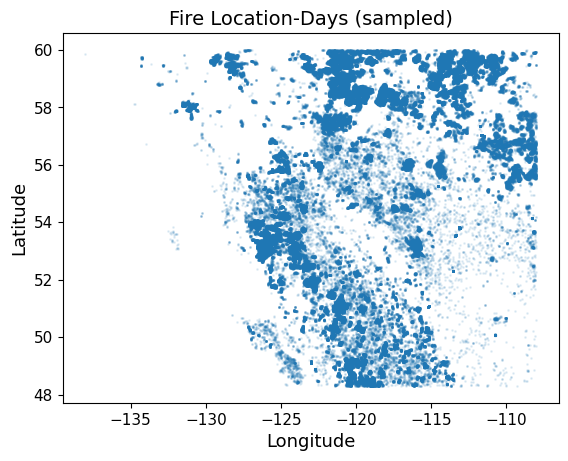

In [ ]:
plot = fire_core.dropna(subset=["Latitude_Fire", "Longitude_Fire", "FRP_max"]).sample(
    n=min(200000, len(fire_core)), random_state=123
)

plt.figure()
plt.scatter(plot["Longitude_Fire"], plot["Latitude_Fire"], s=1, alpha=0.1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire Location-Days (sampled)")
plt.show()


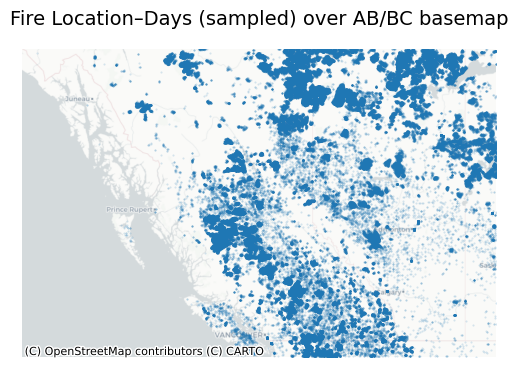

In [ ]:
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer

# Build GeoDataFrame (EPSG:4326)
gdf_pts = gpd.GeoDataFrame(
    plot,  # your sampled df
    geometry=gpd.points_from_xy(plot["Longitude_Fire"], plot["Latitude_Fire"]),
    crs="EPSG:4326"
)

# Project to Web Mercator for basemap tiles
gdf_web = gdf_pts.to_crs(epsg=3857)

# Project sample bounds in lon/lat
min_lon, min_lat, max_lon, max_lat = -139, 48.3, -108, 60

# Convert bounds to EPSG:3857 (Web Mercator)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
minx, miny = transformer.transform(min_lon, min_lat)
maxx, maxy = transformer.transform(max_lon, max_lat)

# Plot
fig, ax = plt.subplots(figsize=(9, 9))
gdf_web.plot(ax=ax, markersize=0.2, alpha=0.2)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

plt.title("Fire Location–Days (sampled) over AB/BC basemap")
plt.axis("off")
plt.show()

## **(2) Meteorological & Land Cover Feature EDA**

### Temperature Distribution

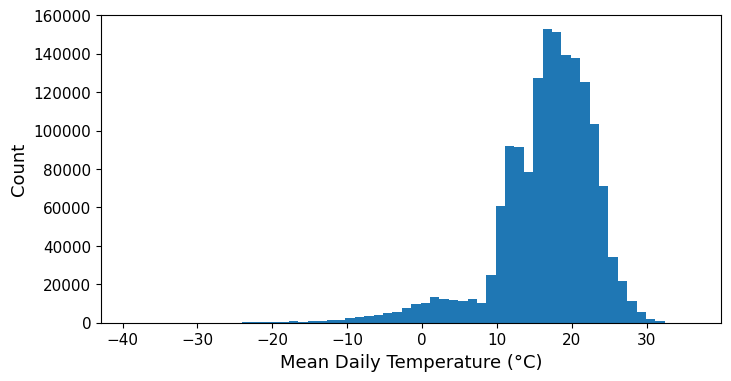

In [ ]:
temp = fire_core["Mean_Temp_C"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(temp, bins=60)
plt.xlabel("Mean Daily Temperature (°C)")
plt.ylabel("Count")
plt.title("Distribution of Mean Daily Temperature at Fire Locations")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.show()

### Precipitation Distribution

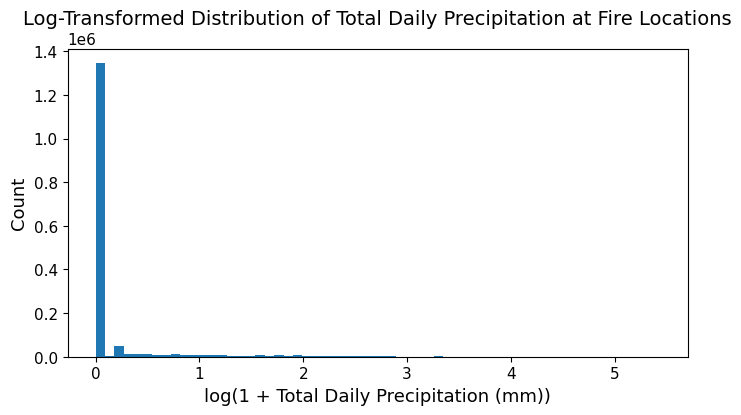

In [ ]:
precip = fire_core["Total_Precip_mm"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(precip), bins=60)
plt.xlabel("log(1 + Total Daily Precipitation (mm))")
plt.ylabel("Count")
plt.title("Log-Transformed Distribution of Total Daily Precipitation at Fire Locations")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.show()

In [ ]:
zero_frac = (precip == 0).mean() * 100
print(f"Percent of fire location–days with zero precipitation: {zero_frac:.1f}%")

Percent of fire location–days with zero precipitation: 86.0%


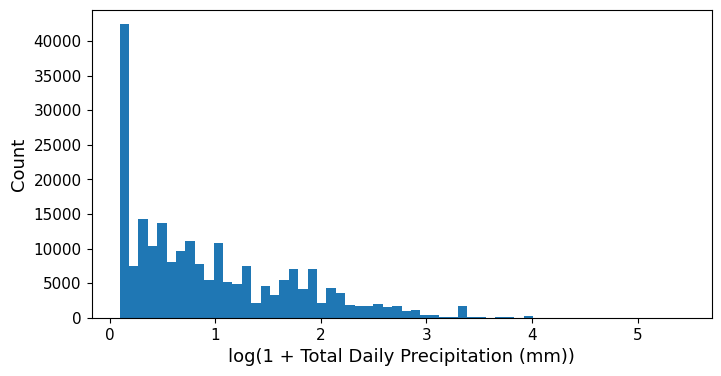

In [ ]:
# Plot non-zero precipitation
precip_nonzero = precip[precip > 0]

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(precip_nonzero), bins=60)
plt.xlabel("log(1 + Total Daily Precipitation (mm))")
plt.ylabel("Count")
plt.title("Log-Transformed Distribution of Total Daily Precipitation at Fire Locations (non-zero only)")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.show()


### Land Cover Fire Frequencies

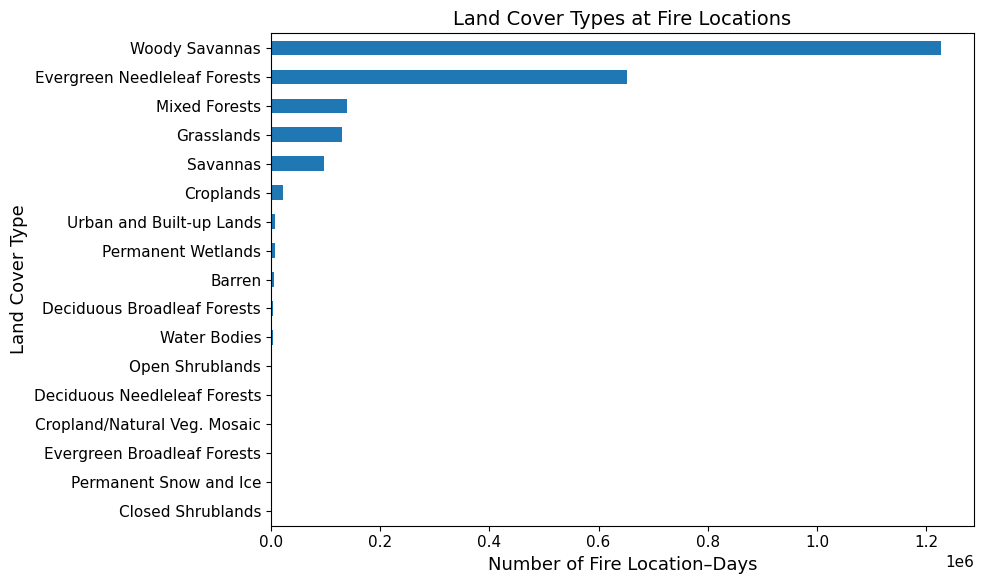

In [ ]:
LC_counts = (
    fire_core["LC_Label"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
LC_counts.plot(kind="barh")
plt.xlabel("Number of Fire Location–Days")
plt.ylabel("Land Cover Type")
plt.title("Land Cover Types at Fire Locations")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.tight_layout()
plt.show()

### Create table for easier interpretation

In [ ]:
LC_table = (
    fire_core["LC_Label"]
    .value_counts()
    .rename("Count")
    .to_frame()
)

LC_table["Percentage"] = 100 * LC_table["Count"] / LC_table["Count"].sum()

LC_table = LC_table.reset_index().rename(columns={"index": "Land Cover Type"})
LC_table["Percentage"] = LC_table["Percentage"].round(2)

LC_table

,LC_Label,Count,Percentage
0,Woody Savannas,1226311,53.30
1,Evergreen Needleleaf Forests,652603,28.37
2,Mixed Forests,138990,6.04
3,Grasslands,129651,5.64
4,Savannas,96418,4.19
5,Croplands,22604,0.98
6,Urban and Built-up Lands,8307,0.36
7,Permanent Wetlands,6856,0.30
8,Barren,6368,0.28
9,Deciduous Broadleaf Forests,3702,0.16


### Wind Gust Distribution

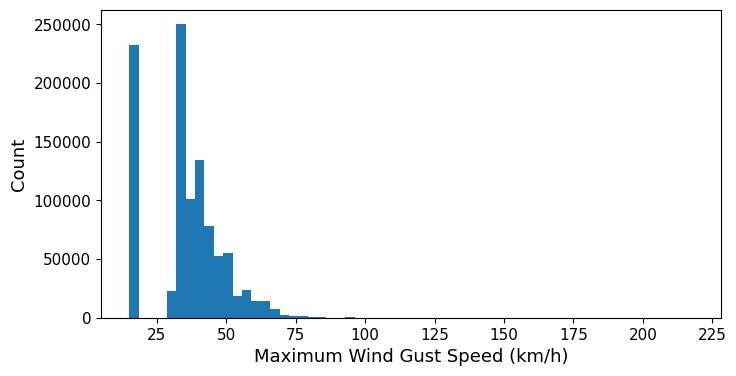

In [ ]:
wind = fire_gust["Max_Gust_Speed_kmh"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(wind, bins=60)
plt.xlabel("Maximum Wind Gust Speed (km/h)")
plt.ylabel("Count")
#plt.title("Distribution of Maximum Daily Wind Gust Speed at Fire Locations")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
plt.show()

## **(3) FRP-Based Threshold Selection**

In [ ]:
# Compute candidate thresholds on full aggregated fire dataset
thresh_p90 = fire_core["FRP_max"].quantile(0.90)
thresh_p95 = fire_core["FRP_max"].quantile(0.95)

print("90th Percentile Threshold Value:", thresh_p90)
print("95th Percentile Threshold Value:", thresh_p95)

90th Percentile Threshold Value: 33.41
95th Percentile Threshold Value: 64.43


### Apply thresholds to fire-core dataset

In [ ]:
# 90th percentile
core_labels_90 = (fire_core["FRP_max"] >= thresh_p90).astype(int)
print(core_labels_90.value_counts(normalize=True))

# 95th percentile
core_labels_95 = (fire_core["FRP_max"] >= thresh_p95).astype(int)
print(core_labels_95.value_counts(normalize=True))

FRP_max
0    0.899972
1    0.100028
Name: proportion, dtype: float64
FRP_max
0    0.949998
1    0.050002
Name: proportion, dtype: float64


### Apply thresholds to fire-core dataset

In [ ]:
# 90th percentile
gust_labels_90 = (fire_gust["FRP_max"] >= thresh_p90).astype(int)
print(gust_labels_90.value_counts(normalize=True))

# 95th percentile
gust_labels_95 = (fire_gust["FRP_max"] >= thresh_p95).astype(int)
print(gust_labels_95.value_counts(normalize=True))

FRP_max
0    0.899972
1    0.100028
Name: proportion, dtype: float64
FRP_max
0    0.949998
1    0.050002
Name: proportion, dtype: float64


In [ ]:
core_model = fire_core.dropna(subset=["Mean_Temp_C", "Total_Precip_mm"]).copy()

core_model_labels_90 = (core_model["FRP_max"] >= thresh_p90).astype(int)
core_model_labels_95 = (core_model["FRP_max"] >= thresh_p95).astype(int)

print("Core (model-ready) – 90th:\n", core_model_labels_90.value_counts(normalize=True))
print("Core (model-ready) – 95th:\n", core_model_labels_95.value_counts(normalize=True))
print("Core model-ready rows:", len(core_model))

Core (model-ready) – 90th:
 FRP_max
0    0.900896
1    0.099104
Name: proportion, dtype: float64
Core (model-ready) – 95th:
 FRP_max
0    0.950205
1    0.049795
Name: proportion, dtype: float64
Core model-ready rows: 1563080


In [ ]:
gust_model = fire_gust.dropna(subset=["Mean_Temp_C", "Total_Precip_mm", "Max_Gust_Speed_kmh"]).copy()

gust_model_labels_90 = (gust_model["FRP_max"] >= thresh_p90).astype(int)
gust_model_labels_95 = (gust_model["FRP_max"] >= thresh_p95).astype(int)

print("Gust (model-ready) – 90th:\n", gust_model_labels_90.value_counts(normalize=True))
print("Gust (model-ready) – 95th:\n", gust_model_labels_95.value_counts(normalize=True))
print("Gust model-ready rows:", len(gust_model))

Gust (model-ready) – 90th:
 FRP_max
0    0.886772
1    0.113228
Name: proportion, dtype: float64
Gust (model-ready) – 95th:
 FRP_max
0    0.942032
1    0.057968
Name: proportion, dtype: float64
Gust model-ready rows: 1011445


## **(4) Finalize Datasets for Modeling**

In [ ]:
# Define threshold
FRP_thesh_90 = 33.41

# Add binary intensity labels to both datasets
fire_core["High_Intensity"] = (fire_core["FRP_max"] >= FRP_thesh_90).astype(int)
fire_gust["High_Intensity"] = (fire_core["FRP_max"] >= FRP_thesh_90).astype(int)

# Drop rows with missing predictors
core_model = fire_core.dropna(
    subset=["Mean_Temp_C", "Total_Precip_mm"]
    ).copy()

gust_model = fire_gust.dropna(
    subset=["Mean_Temp_C", "Total_Precip_mm", "Max_Gust_Speed_kmh"]
    ).copy()

print("Core model-ready rows:", len(core_model))
print(core_model["High_Intensity"].value_counts(normalize=True))

print("\nGust model-ready rows:", len(gust_model))
print(gust_model["High_Intensity"].value_counts(normalize=True))

Core model-ready rows: 1563080
High_Intensity
0    0.900896
1    0.099104
Name: proportion, dtype: float64

Gust model-ready rows: 1011445
High_Intensity
0    0.886772
1    0.113228
Name: proportion, dtype: float64


In [ ]:
print("Core Columns:", core_model.columns)
print("_________________________________________________________________________________________")
print("Gust Columns:", gust_model.columns)

Core Columns: Index(['Fire_ID', 'Acquisition_Time', 'Year', 'Month', 'Day_of_Year', 'Hour',
       'Latitude_Fire', 'Longitude_Fire', 'Bright_TI4', 'Bright_TI5', 'FRP',
       'Scan', 'Track', 'Confidence', 'DayNight', 'Fire_Type', 'LC_Type1',
       'LC_Label', 'Confidence_Ordered', 'detection_count', 'FRP_max', 'Date',
       'Nearest_Core_Station_Dist_km', 'Climate_ID', 'Station_Name',
       'Province', 'Elevation_m', 'Latitude_Weather', 'Longitude_Weather',
       'Max_Temp_C', 'Min_Temp_C', 'Mean_Temp_C', 'Total_Precip_mm',
       'Core_Dist_75km', 'Core_Dist_100km', 'High_Intensity'],
      dtype='object')
___________________________________________________________________________________
Gust Columns: Index(['Fire_ID', 'Acquisition_Time', 'Year', 'Month', 'Day_of_Year', 'Hour',
       'Latitude_Fire', 'Longitude_Fire', 'Bright_TI4', 'Bright_TI5', 'FRP',
       'Scan', 'Track', 'Confidence', 'DayNight', 'Fire_Type', 'LC_Type1',
       'LC_Label', 'Confidence_Ordered', 'detection

### Select column subset for modeling stage

In [ ]:
# Baseline core model columns
core_columns = [
    "High_Intensity",
    "Mean_Temp_C",
    "Total_Precip_mm",
    "LC_Type1",
    "Month",
    "Day_of_Year",
    "Latitude_Fire",
    "Longitude_Fire",
    "Elevation_m",
    "FRP_max",
    "Fire_ID",
    "Climate_ID",
    "LC_Label",
    "Nearest_Core_Station_Dist_km",
    "Core_Dist_75km",
    "Core_Dist_100km",
    "Confidence_Ordered",
    "DayNight",
    "Hour",
    "Year",
    "Province"
]

# Extended gust model columns
gust_columns = [
    "High_Intensity",
    "Mean_Temp_C",
    "Total_Precip_mm",
    "Max_Gust_Speed_kmh",
    "LC_Type1",
    "Month",
    "Day_of_Year",
    "Latitude_Fire",
    "Longitude_Fire",
    "Elevation_m",
    "FRP_max",
    "Fire_ID",
    "Climate_ID",
    "LC_Label",
    "Gust_Flag_Threshold",
    "Gust_Flag_Imputed",
    "Imputed_Radius_km",
    "Nearest_Gust_Station_Dist_km",
    "Gust_Dist_75km",
    "Gust_Dist_100km",
    "Confidence_Ordered",
    "DayNight",
    "Hour",
    "Year",
    "Province"
]

# Create copy of each with subset of columns
core_model_final = core_model[core_columns].copy()
gust_model_final = gust_model[gust_columns].copy()

In [ ]:
print("Core Columns:", core_model_final.columns)
print("___________________________________________________________________________________")
print("Gust Columns:", gust_model_final.columns)

Core Columns: Index(['High_Intensity', 'Mean_Temp_C', 'Total_Precip_mm', 'LC_Type1', 'Month',
       'Day_of_Year', 'Latitude_Fire', 'Longitude_Fire', 'Elevation_m',
       'FRP_max', 'Fire_ID', 'Climate_ID', 'LC_Label',
       'Nearest_Core_Station_Dist_km', 'Core_Dist_75km', 'Core_Dist_100km',
       'Confidence_Ordered', 'DayNight', 'Hour', 'Year', 'Province'],
      dtype='object')
___________________________________________________________________________________
Gust Columns: Index(['High_Intensity', 'Mean_Temp_C', 'Total_Precip_mm',
       'Max_Gust_Speed_kmh', 'LC_Type1', 'Month', 'Day_of_Year',
       'Latitude_Fire', 'Longitude_Fire', 'Elevation_m', 'FRP_max', 'Fire_ID',
       'Climate_ID', 'LC_Label', 'Gust_Flag_Threshold', 'Gust_Flag_Imputed',
       'Imputed_Radius_km', 'Nearest_Gust_Station_Dist_km', 'Gust_Dist_75km',
       'Gust_Dist_100km', 'Confidence_Ordered', 'DayNight', 'Hour', 'Year',
       'Province'],
      dtype='object')


### Save finalized subsets for modeling

In [ ]:
core_model_final.to_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Model_Core_Final.csv", index=False)

gust_model_final.to_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Model_Gust_Final.csv", index=False)